<a href="https://colab.research.google.com/github/banana550/nyc_taxi/blob/main/notebooks/02_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Выполнение задания в Google Colab

## Шаг 1. Проверка версии интерпретатора Python
Сравнение версии Python, используемой в Google Colab, с целевой версией курса (3.12.14).

In [1]:
import sys

print(f"Версия Python в Colab: {sys.version}")
print("Требуемая версия в курсе: 3.12.14")

Версия Python в Colab: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Требуемая версия в курсе: 3.12.14


## Шаг 2. Установка и вывод версий библиотек pandas и polars
Устанавливаем и обновляем библиотеки `pandas` и `polars` через команду `!pip install`, после чего выводим их текущие версии.

In [2]:
!pip install --upgrade pandas polars matplotlib seaborn -q

import pandas as pd
import polars as pl

print(f"Версия pandas: {pd.__version__}")
print(f"Версия polars: {pl.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.8/865.8 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 112.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
Версия pandas: 3.0.6
Версия polars: 1.44.2


## Шаг 3 и 4. Загрузка, чтение и первичный анализ среза данных
Загружаем отладочный срез данных `sample_200k.csv` из сеансового хранилища, выводим размерность, типы столбцов и долю пропусков по каждому столбцу.

In [3]:
from pathlib import Path

DATA_PATH = Path("sample_200k.csv")
df = pl.read_csv(DATA_PATH)

print(
    f"Число строк: {df.shape[0]:,}, Число столбцов: {df.shape[1]}\n" + "-" * 50
)

print("Перечень столбцов и их типы:")
for col_name, dtype in zip(df.columns, df.dtypes):
    print(f" - {col_name}: {dtype}")
print("-" * 50)

print("Доля пропусков по столбцам:")
null_counts = df.null_count()
for col_name in df.columns:
    null_ratio = null_counts[col_name][0] / df.shape[0]
    print(f" - {col_name}: {null_ratio:.4%}")

Число строк: 26,717, Число столбцов: 19
--------------------------------------------------
Перечень столбцов и их типы:
 - VendorID: Int64
 - tpep_pickup_datetime: String
 - tpep_dropoff_datetime: String
 - passenger_count: Int64
 - trip_distance: Float64
 - pickup_longitude: Float64
 - pickup_latitude: Float64
 - RateCodeID: Int64
 - store_and_fwd_flag: String
 - dropoff_longitude: Float64
 - dropoff_latitude: Float64
 - payment_type: Int64
 - fare_amount: Float64
 - extra: Float64
 - mta_tax: Float64
 - tip_amount: Float64
 - tolls_amount: Float64
 - improvement_surcharge: Float64
 - total_amount: Float64
--------------------------------------------------
Доля пропусков по столбцам:
 - VendorID: 0.0000%
 - tpep_pickup_datetime: 0.0000%
 - tpep_dropoff_datetime: 0.0037%
 - passenger_count: 0.0037%
 - trip_distance: 0.0037%
 - pickup_longitude: 0.0037%
 - pickup_latitude: 0.0037%
 - RateCodeID: 0.0037%
 - store_and_fwd_flag: 0.0037%
 - dropoff_longitude: 0.0037%
 - dropoff_latitude: 0.

## Шаг 5. Предобработка, очистка аномалий и сохранение
Приводим текстовые даты к формату `Datetime`, рассчитываем длительность поездки, фильтруем аномалии на основе требований `DATASET.md` и сохраняем очищенный срез.

In [5]:
df_clean = df.with_columns(
    [
        pl.col("tpep_pickup_datetime").str.to_datetime(strict=False),
        pl.col("tpep_dropoff_datetime").str.to_datetime(strict=False),
    ]
).with_columns(
    (
        (
            pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")
        ).dt.total_seconds()
        / 60
    ).alias("duration_minutes")
)

df_filtered = df_clean.filter(
    (pl.col("duration_minutes") > 0)
    & (pl.col("duration_minutes") <= 1440)
    & (pl.col("pickup_longitude") != 0)
    & (pl.col("pickup_latitude") != 0)
    & (pl.col("dropoff_longitude") != 0)
    & (pl.col("dropoff_latitude") != 0)
    & (pl.col("fare_amount") > 0)
    & (pl.col("total_amount") > 0)
    & (pl.col("passenger_count") > 0)
)

print(f"Записи до очистки:  {df.shape[0]:,}")
print(f"Записи после очистки: {df_filtered.shape[0]:,}")

df_filtered.write_csv("sample_200k_cleaned.csv")
print("Файл sample_200k_cleaned.csv успешно сохранен в сессию.")

Записи до очистки:  26,717
Записи после очистки: 26,157
Файл sample_200k_cleaned.csv успешно сохранен в сессию.


## Шаг 6. Визуализация распределения числового столбца
Строим гистограмму распределения значений столбца `fare_amount` (стоимость поездки) для очищенного датасета.

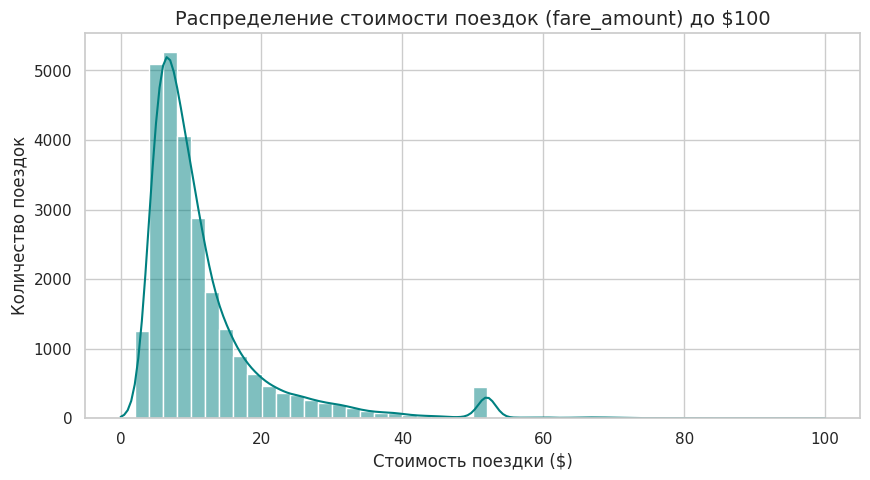

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fare_data = df_filtered.filter(pl.col("fare_amount") <= 100)[
    "fare_amount"
].to_numpy()

plt.figure(figsize=(10, 5))
sns.histplot(fare_data, bins=50, kde=True, color="teal")

plt.title("Распределение стоимости поездок (fare_amount) до $100", fontsize=14)
plt.xlabel("Стоимость поездки ($)", fontsize=12)
plt.ylabel("Количество поездок", fontsize=12)

plt.show()